In [93]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [94]:
df1=pd.read_csv(r"C:\Users\EXIRIM_Compurer's\Desktop\python\kc_house_data.csv")
df=df1.copy()
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [95]:
df.shape

(21613, 21)

In [96]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [98]:
df['date']=pd.to_datetime(df['date'])
df['date'].dtype



dtype('<M8[ns]')

<Axes: >

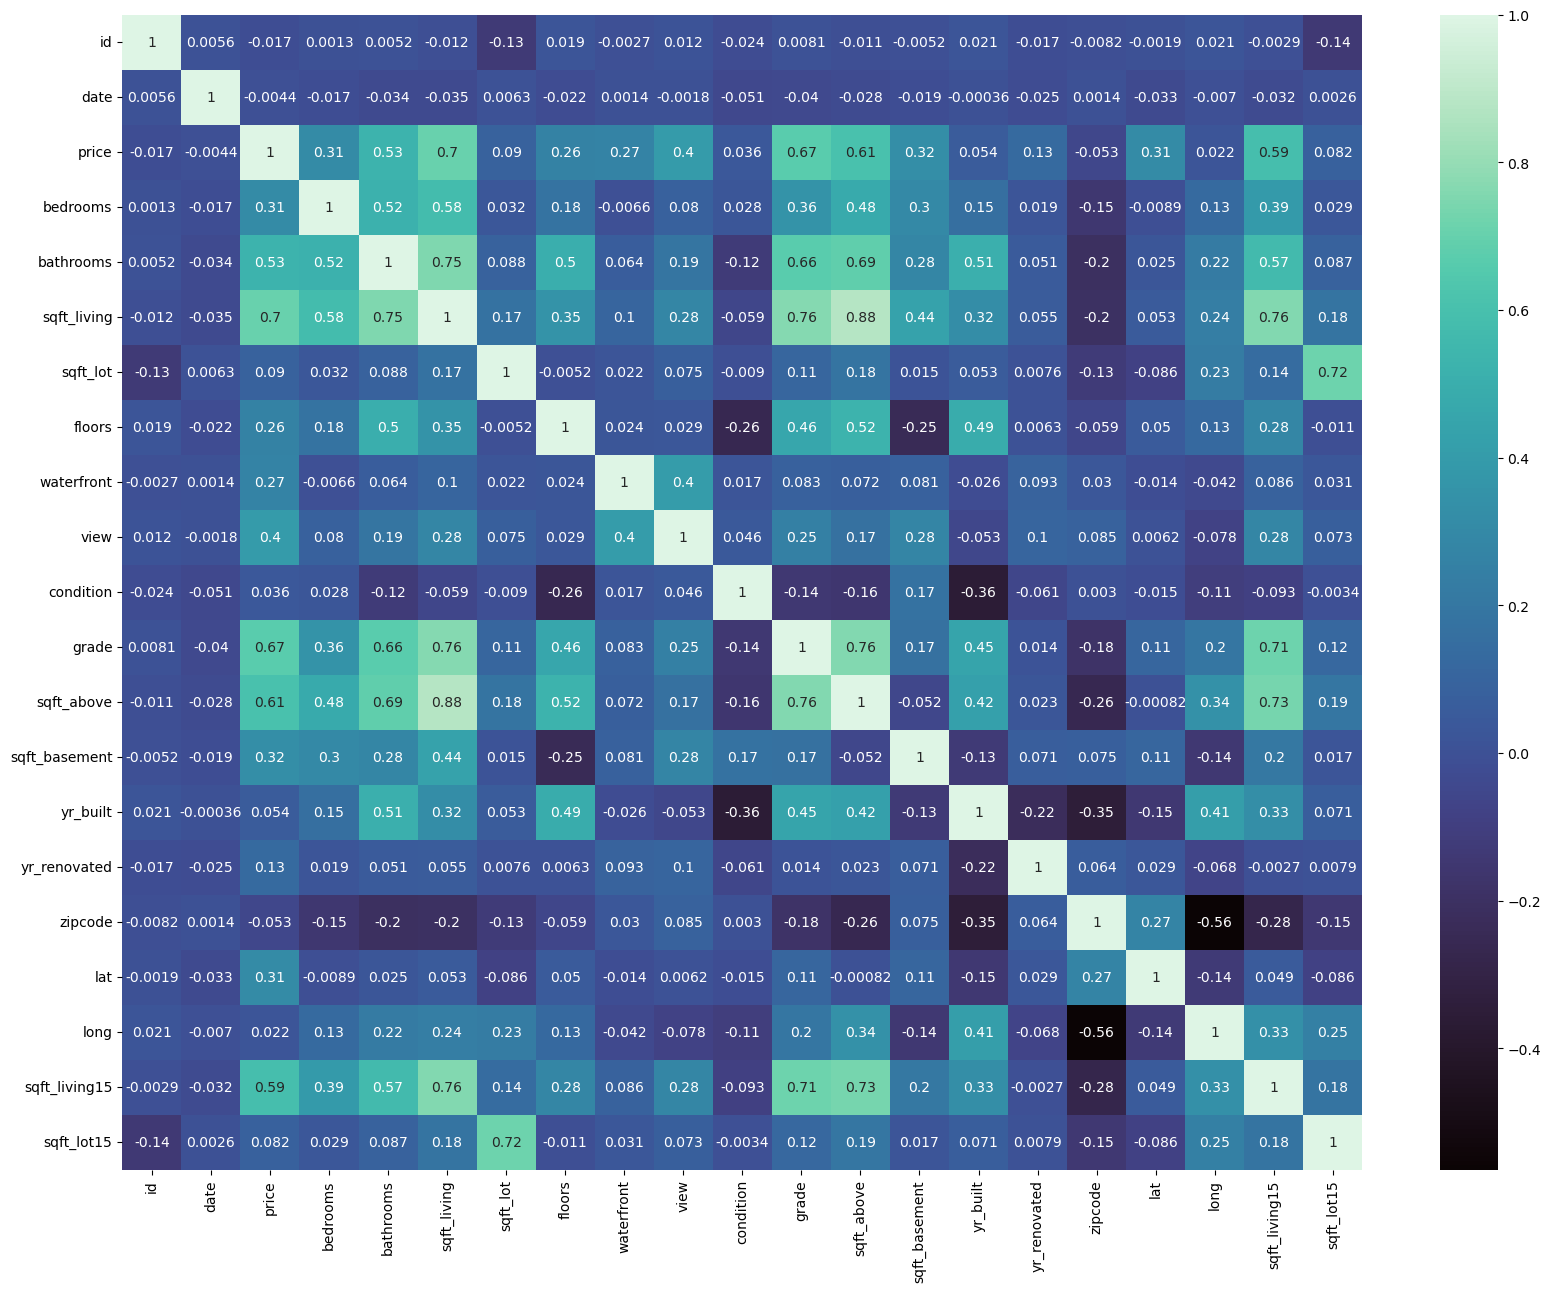

In [100]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True,cmap='mako')    

In [101]:
df.corr()['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
date            -0.004357
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

In [102]:
corr_target=df.corr()['price']
low_corr_cols = corr_target[corr_target < 0.08].index
df = df.drop(columns=low_corr_cols)
df.shape

(21613, 15)

<Axes: >

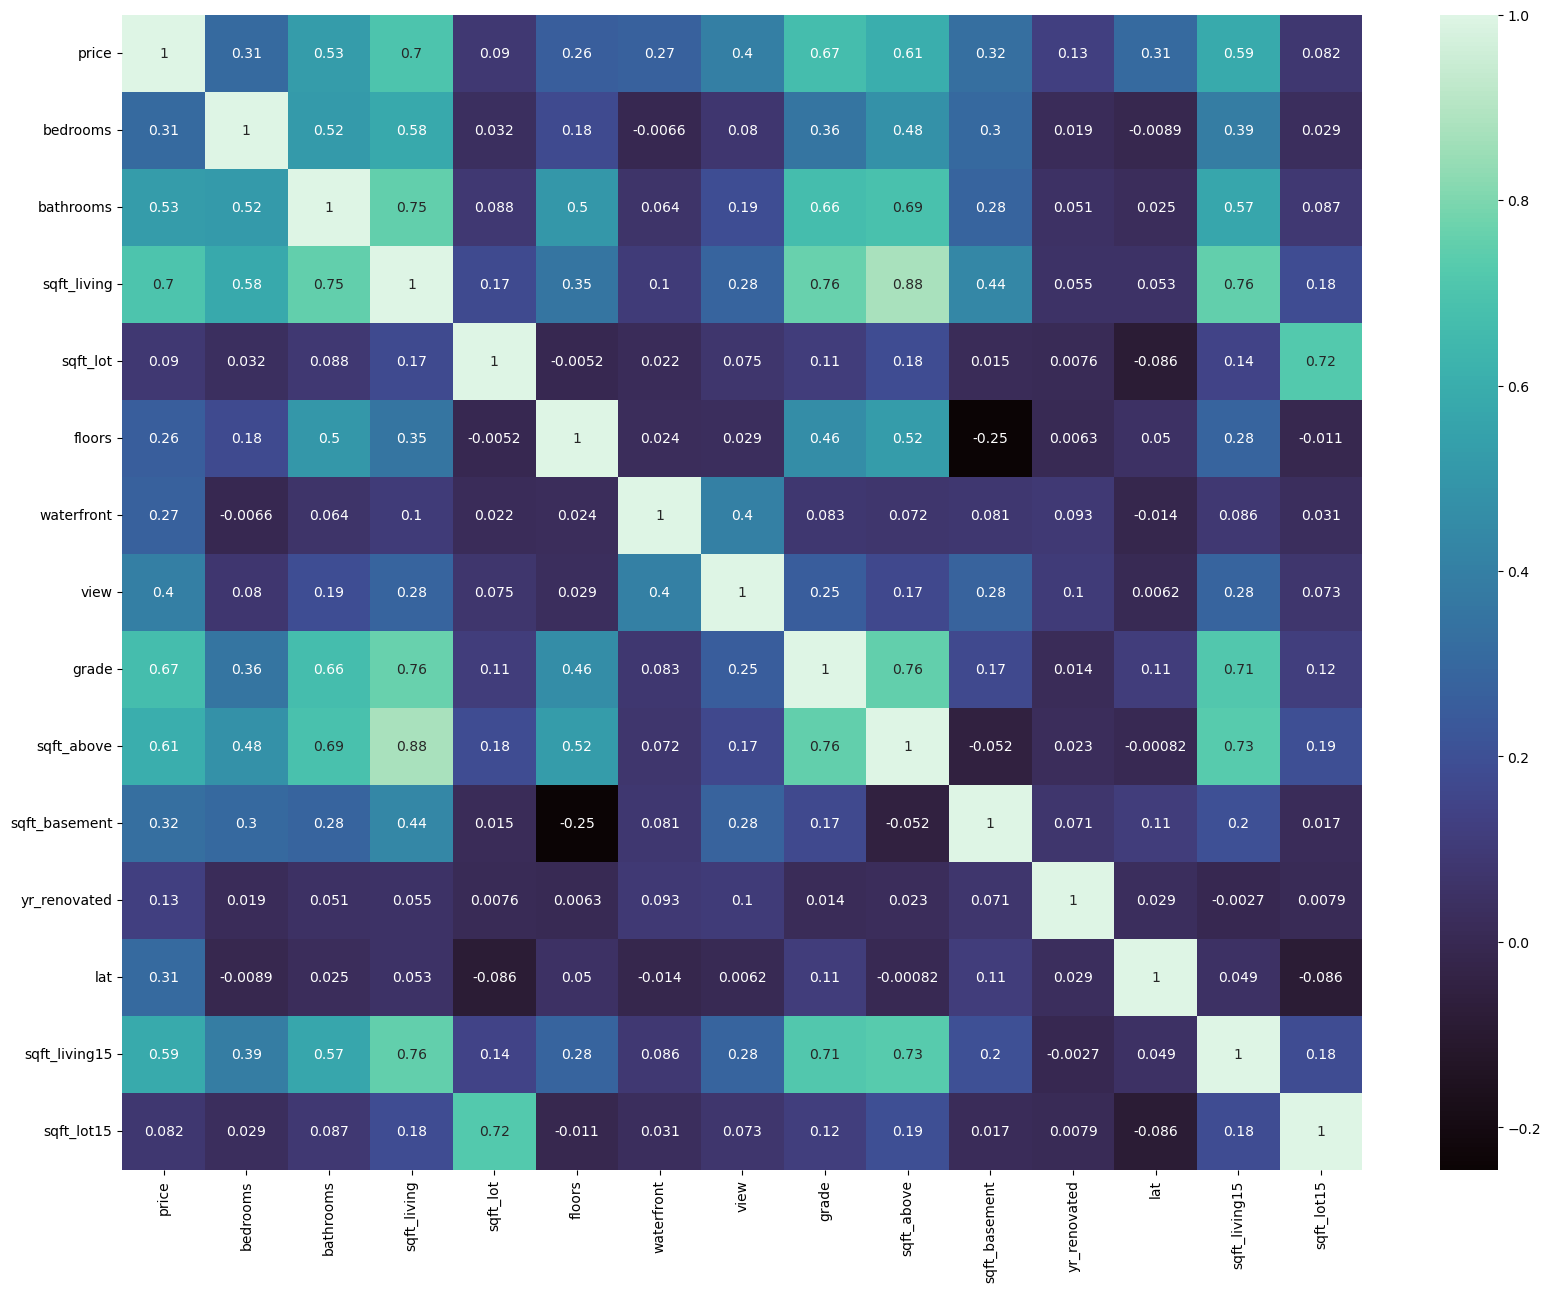

In [103]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True,cmap='mako')    

In [114]:
# df=df.drop(['sqft_living15','sqft_above'],axis=1)
df=df.drop(['sqft_lot15'],axis=1)
df.shape

(21613, 12)

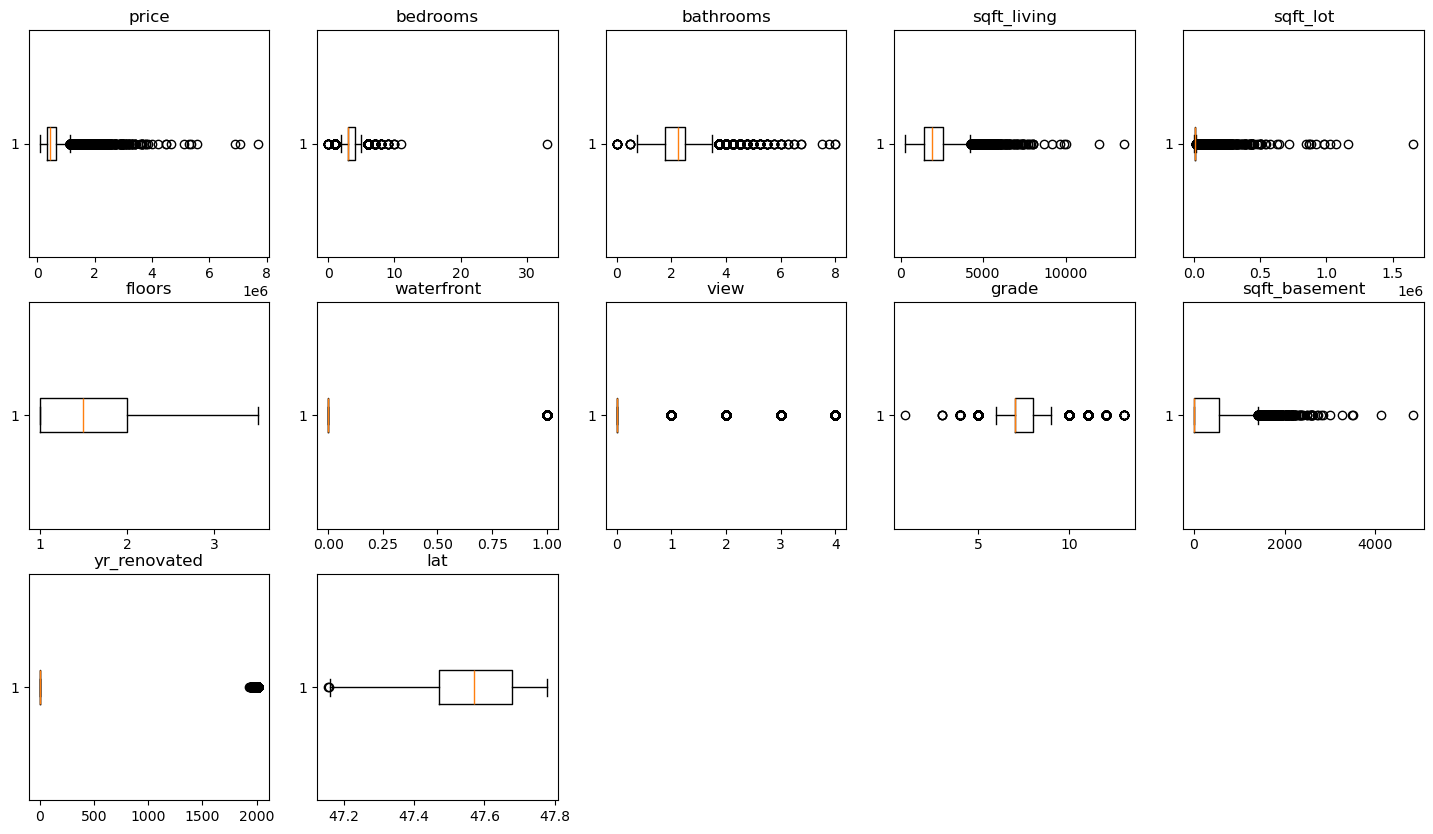

In [115]:
num_cols=df.select_dtypes(include='number').columns
plt.figure(figsize=(18,10))
for i,col in enumerate(num_cols):
    plt.subplot(3,5,i+1)
    plt.boxplot(df[col],vert=False)
    plt.title(col)
plt.show()
    

In [117]:
out_cols=['bedrooms','bathrooms','sqft_living']
for col in out_cols:
   q1,q3=np.percentile(df[col],[25,75])
   iqr=q3-q1
   lower=q1-1.5*iqr
   upper=q3+1.5*iqr
   df=df[(df[col]>=lower) & (df[col]<=upper)]

In [118]:
df.shape

(20229, 12)

In [122]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [120]:
X=df.drop('price',axis=1)
y=df['price']

In [121]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [123]:
pipe_linear=Pipeline([
    ('std',StandardScaler()),
    ('model',LinearRegression())
])

pipe_linear.fit(X_train,y_train)

Pipeline(steps=[('std', StandardScaler()), ('model', LinearRegression())])

In [124]:
y_pred_linear=pipe_linear.predict(X_test)

In [126]:
from sklearn.metrics import  r2_score,mean_squared_error,mean_absolute_error



In [130]:
y_pred = pipe_linear.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)


R2: 0.6147086857925259
MAE: 110788.81872062817
RMSE: 160167.13067010863


In [131]:
y_train_pred = pipe_linear.predict(X_train)
print("Train R2:", r2_score(y_train, y_train_pred))


y_test_pred = pipe_linear.predict(X_test)
print("Test R2:", r2_score(y_test, y_test_pred))


Train R2: 0.6240441357046296
Test R2: 0.6147086857925259


In [132]:
from sklearn.tree import DecisionTreeRegressor

In [171]:
pipe_tree=Pipeline([
    ('tree',DecisionTreeRegressor(max_depth=10,min_samples_leaf=10,random_state=42))
])

pipe_tree.fit(X_train,y_train)
y_pred_tree=pipe_tree.predict(X_test)

In [172]:
y_pred_tree= pipe_tree.predict(X_test)

print("R2:", r2_score(y_test, y_pred_tree))
print("MAE:", mean_absolute_error(y_test, y_pred_tree))
print("RMSE:", mean_squared_error(y_test, y_pred_tree)**0.5)


R2: 0.7170001816396329
MAE: 85265.19487787707
RMSE: 137268.80866077187


In [173]:
y_train_pred_t = pipe_tree.predict(X_train)
print("Train R2:", r2_score(y_train, y_train_pred_t))


y_test_pred_t = pipe_tree.predict(X_test)
print("Test R2:", r2_score(y_test, y_test_pred_t))


Train R2: 0.7944344769644728
Test R2: 0.7170001816396329


In [174]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

params = {
    'tree__max_depth': randint(5, 30),
    'tree__min_samples_leaf': randint(1, 20),
    'tree__min_samples_split': randint(2, 20)
}

random_search = RandomizedSearchCV(
    pipe_tree,
    param_distributions=params,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tree',
                                              DecisionTreeRegressor(max_depth=10,
                                                                    min_samples_leaf=10,
                                                                    random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'tree__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001A8DE69B770>,
                                        'tree__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001A8E2D3FC50>,
                                        'tree__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001A8E2D3F250>},
                   random_state=42, scoring='r2')

In [176]:
best_tree = random_search.best_estimator_

print("Train R2:", best_tree.score(X_train, y_train))
print("Test R2:", best_tree.score(X_test, y_test))


Train R2: 0.7944344769644728
Test R2: 0.7170001816396329
